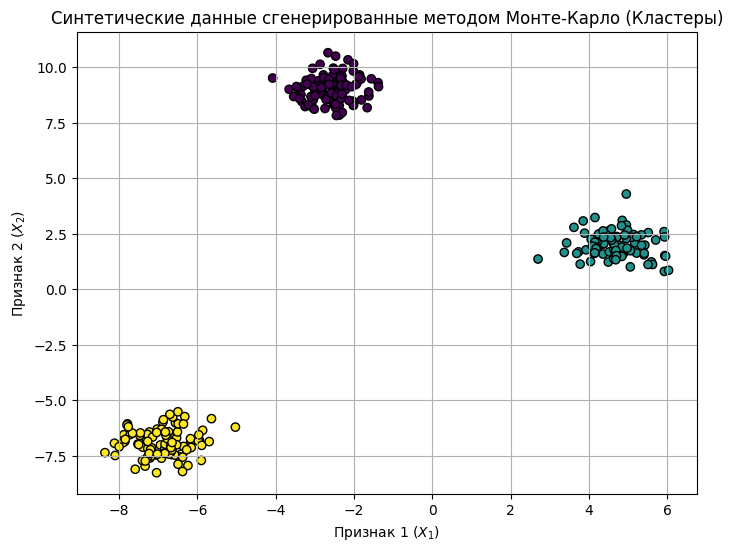

In [9]:
import numpy as np
from sklearn.datasets import make_blobs
import matplotlib.pyplot as plt

# 1. Задаем параметры генерации
n_samples = 300      # Общее количество точек
n_features = 2       # Количество измерений (признаков)
centers = 3          # Количество кластеров 
cluster_std = 0.6    # Стандартное отклонение (разброс точек внутри кластера)

# 2. Генерируем данные с помощью метода Монте-Карло (через генератор случайных величин)
X, y = make_blobs(n_samples=n_samples, n_features=n_features, 
                  centers=centers, cluster_std=cluster_std, random_state=42)

# 3. Визуализируем полученные данные
plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='viridis', marker='o', edgecolor='k')
plt.title('Синтетические данные сгенерированные методом Монте-Карло (Кластеры)')
plt.xlabel('Признак 1 ($X_1$)')
plt.ylabel('Признак 2 ($X_2$)')
plt.grid(True)
plt.show()


In [ ]:
import numpy as np

def wolf_step(lattice, T):
    """Один шаг алгоритма Вольфа для двумерной модели Изинга."""
    L = lattice.shape[0]
    P_add = 1.0 - np.exp(-2.0 / T)  # Вероятность добавления в кластер (J=1, k_B=1)
    
    # Выбираем случайный начальный спин (корень кластера)
    x, y = np.random.randint(0, L, size=2)
    spin_value = lattice[x, y]
    
    cluster = [(x, y)]
    queue = [(x, y)]
    visited = set([(x, y)])
    
    while queue:
        cx, cy = queue.pop(0)
        # Проверяем 4-х соседей с периодическими граничными условиями
        for nx, ny in [((cx+1)%L, cy), ((cx-1)%L, cy), (cx, (cy+1)%L), (cx, (cy-1)%L)]:
            if (nx, ny) not in visited and lattice[nx, ny] == spin_value:
                if np.random.rand() < P_add:
                    queue.append((nx, ny))
                    cluster.append((nx, ny))
                    visited.add((nx, ny))
                    
    # Переворачиваем весь кластер
    for cx, cy in cluster:
        lattice[cx, cy] *= -1
    return lattice

def generate_dataset(L, temperatures, samples_per_T, steps_equilibration=500, steps_sample=100):
    """Генерация снимков решеток для разных температур."""
    data = []
    labels = [] # Температуры
    
    for T in temperatures:
        # Инициализация случайной решеткой
        lattice = np.random.choice([-1, 1], size=(L, L))
        
        # Выход на термодинамическое равновесие
        for _ in range(steps_equilibration):
            lattice = wolf_step(lattice, T)
            
        # Сбор сэмплов
        for _ in range(samples_per_T):
            for _ in range(steps_sample):
                lattice = wolf_step(lattice, T)
            data.append(lattice.copy())
            labels.append(T)
            
    return np.array(data), np.array(labels)

# Пример сборки данных (для решетки 32x32)
L = 32
# Обучаем на экстремумах (T < 2.0 — ферромагнетик, T > 2.6 — парамагнетик)
T_low = np.linspace(1.0, 2.0, 10)
T_high = np.linspace(2.6, 3.5, 10)
T_train = np.concatenate([T_low, T_high])

X_train, y_train_T = generate_dataset(L, T_train, samples_per_T=100)
# Метки: 0 для низких температур (Ordered), 1 для высоких (Disordered)
y_train = np.array([0 if t < 2.269 else 1 for t in y_train_T])
